# Random Fourier Features for Scalable Kernels


The following tutorial is based on [Random Features for Large-Scale Kernel Machines](https://proceedings.neurips.cc/paper/2007/file/013a006f03dbc5392effeb8f18fda755-Paper.pdf) by Ali Rahimi and Benjamin Recht.

# Introduction

## 1. The Kernel Bottleneck
The **Representer Theorem** states that the optimal function $f^*$ can be expressed as:
$$f^*(\mathbf{x}) = \sum_{i=1}^N \alpha_i K(\mathbf{x}, \mathbf{x}_i),$$

where $x_i$ for $i=1,\dots,N$ are the data points. While powerful, this poses significant computational challenges for large $N$:
* **Training Time:** Solving for $\alpha$ typically requires inverting an $N \times N$ matrix, costing $O(N^3)$.
* **Memory:** Storing the Gram matrix $K$ requires $O(N^2)$ space.
* **Inference:** Predicting on a new point requires $O(N)$ kernel evaluations.

---

## 2. Bochner’s Theorem


The breakthrough by Rahimi and Recht relies on **Bochner's Theorem**, which characterizes shift-invariant kernels $K(\mathbf{x}, \mathbf{y}) = k(\mathbf{x} - \mathbf{y})$. It states that such a kernel is the Fourier transform of a positive finite measure $p(\omega)$:
$$k(\mathbf{x} - \mathbf{y}) = \int p(\omega) e^{i \omega^\top (\mathbf{x} - \mathbf{y})} d\omega = E_{\omega} [e^{i \omega^\top \mathbf{x}} e^{-i \omega^\top \mathbf{y}}]$$

Example: for the **Gaussian kernel** also called **Radial Basis Function (RBF)**:
$$K(\mathbf{x}, \mathbf{y}) = \exp\left(-\frac{\|\mathbf{x} - \mathbf{y}\|^2}{2\sigma^2}\right)$$
The corresponding density $p(\omega)$ is a Gaussian distribution: $\mathcal{N}(0, \sigma^{-2}\mathbf{I})$.

---

## 3. Random Fourier Feature Mapping
The idea is to estimate the integral with a finite sum. We define a randomized feature map $\mathbf{z}(\mathbf{x}): \mathbb{R}^D \to \mathbb{R}^R$ such that $K(\mathbf{x}, \mathbf{y}) \approx \mathbf{z}(\mathbf{x})^\top \mathbf{z}(\mathbf{y})$.

The mapping is defined as:
$$\mathbf{z}(\mathbf{x}) = \sqrt{\frac{2}{R}} \begin{bmatrix} \cos(\omega_1^\top \mathbf{x} + b_1) \\ \cos(\omega_2^\top \mathbf{x} + b_2) \\ \vdots \\ \cos(\omega_R^\top \mathbf{x} + b_R) \end{bmatrix}=\sqrt{\frac{2}{R}}\cos(\boldsymbol{\Omega} \mathbf{x} + \mathbf{b})$$

Where the random parameters are sampled as:
* **Spectral Weights:** $\omega_j \sim \mathcal{N}(0, \sigma^{-2}\mathbf{I})$
* **Random Phase:** $b_j \sim \text{Uniform}(0, 2\pi)$

$f^*$ can be computed with classical linear ridge regression
$$f^*(x)=\theta^T\mathbf{z}(x).$$
It only requires $O(D\cdot R)$ operations per prediction compared to $O(N\cdot D)$ for classical kernel ridge regression.





To begin with, we will work with data points sampled from a S curve in dimension 3. The following code generate the date set and plot it.

In [1]:
import matplotlib.pyplot as plt
from matplotlib import ticker
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.datasets import make_s_curve


N    = 1000 #Number of data points
D    = 3 #Dimension of the Data
X, t = make_s_curve(N, noise=0.1)

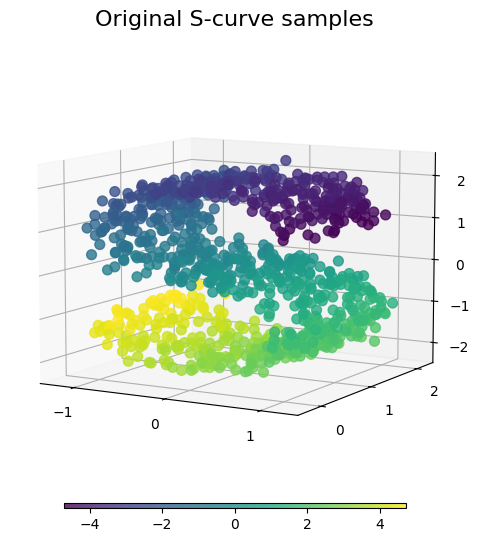

In [2]:
def plot_3d(points, points_color, title):
    x, y, z = points.T

    fig, ax = plt.subplots(
        figsize=(6, 6),
        facecolor="white",
        tight_layout=True,
        subplot_kw={"projection": "3d"},
    )
    fig.suptitle(title, size=16)
    col = ax.scatter(x, y, z, c=points_color, s=50, alpha=0.8)
    ax.view_init(azim=-60, elev=9)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.zaxis.set_major_locator(ticker.MultipleLocator(1))

    fig.colorbar(col, ax=ax, orientation="horizontal", shrink=0.6, aspect=60, pad=0.01)
    plt.show()

plot_3d(X, t, "Original S-curve samples")

In [3]:
X = X[t.argsort()]

To use the RBF kernel we will use the [`rbf_kernel`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.rbf_kernel.html) function from sklearn.metrics.pairwise. It takes as arguments the dataset X and gamma$=1/2\sigma^2$ and generates the associated Gram matrix.

1. Complete the following the code. The goal is to compare visually the exact Gram matrix of the RBF with the one approximated by Random Fourier Features for different values of $R$. Comment.

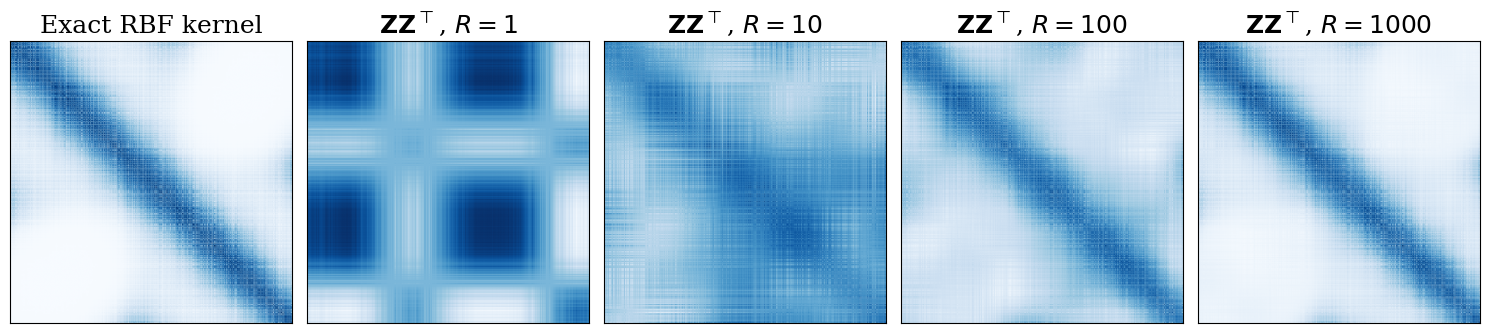

In [8]:
fig, axes = plt.subplots(1, 5)
fig.set_size_inches(15, 4)
font = {'fontname': 'serif', 'fontsize': 18}

gamma = 1/2.
# The RBF kernel is the Gaussian kernel.
K = rbf_kernel(X, gamma=gamma)

axes[0].imshow(K, cmap=plt.cm.Blues)
axes[0].set_title('Exact RBF kernel', **font)
axes[0].set_xticks([])
axes[0].set_yticks([])

sigma = 1.

for R, ax in zip([1, 10, 100, 1000], axes[1:]):

    W    = np.random.normal(  size=(R, D))
    B    = np.random.uniform(0, 2*np.pi, size=(R,1))
    norm = 1./ np.sqrt(R)
    Z    = norm * np.sqrt(2) * np.cos(sigma*W @ X.T + B)
    ZZ   = Z.T@Z
    ax.imshow(ZZ, cmap=plt.cm.Blues)
    ax.set_title(r'$\mathbf{Z} \mathbf{Z}^{\top}$, $R=%s$' % R, **font)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

We are going to create a toy Gaussian model for the dataset that we want to fit.


In [9]:
from   sklearn.gaussian_process.kernels import RBF

N     = 100
X     = np.linspace(-10, 10, 2*N)[:, None]

mean  = np.zeros(X.shape[0])
cov   = RBF()(X)
y_true = np.random.multivariate_normal(mean, cov)

noise = np.random.normal(0, 0.5, 2*N)
y    = y_true + noise

X_train =  X[::2]#[:, None]
y_train = y[::2]#[:, None]

/tmp/ipython-input-968960982.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = plt.cm.get_cmap('Blues')


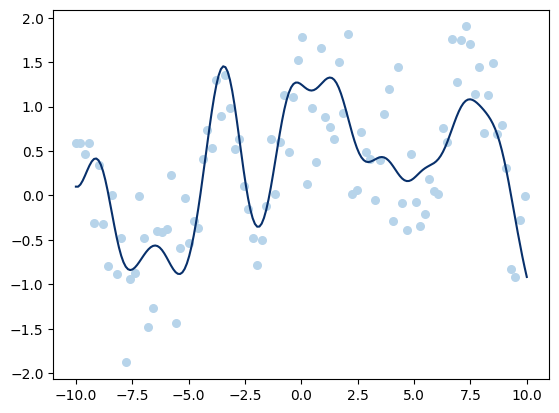

In [10]:
cmap      = plt.cm.get_cmap('Blues')
plt.plot(X, y_true, c=cmap(1.))
plt.scatter(X_train, y_train, s=30, c=[cmap(0.3)])
plt.show()

2. Write a code that fits the data with classical Kernel ridge regression using a RBF kernel. We are going to use the function [`KernelRidge`](https://scikit-learn.org/stable/modules/generated/sklearn.kernel_ridge.KernelRidge.html).

In [11]:
from sklearn.kernel_ridge import KernelRidge

# 1. Initialize the model.
# We use the 'rbf' kernel.
# 'alpha' is the regularization (similar to the noise we added).
# 'gamma' defines the width of the Gaussian (1/(2*sigma**2)).
krr = KernelRidge(kernel='rbf',  alpha=1.,gamma=0.5)

# 2. Fit the model to the training data
krr.fit(X_train, y_train)

# 3. Predict on the full range X to see how it interpolates
y_pred = krr.predict(X)

/tmp/ipython-input-1057168514.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = plt.cm.get_cmap('Blues')


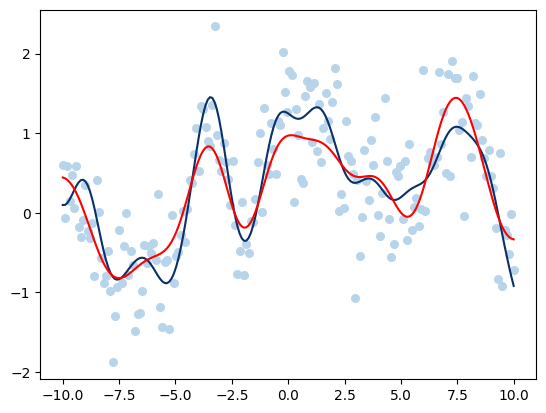

In [12]:
cmap      = plt.cm.get_cmap('Blues')
plt.plot(X, y_true, c=cmap(1.))
plt.scatter(X, y, s=30, c=[cmap(0.3)])
plt.plot(X, y_pred, c='red')
plt.show()

We want to compare the performances of the exact Kernel Ridge Regression (KRR) with the ones of Random Fourier Features Ridge Regression (RFFRR).

3. Complete the following code. The goal is to map the inputs into a randomized feature space and then to use standard linear ridge regression. We are going to use the [`Ridge`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) function.

In [13]:
from   sklearn.linear_model import Ridge
from   sklearn.exceptions import NotFittedError

class RFFRidgeRegression:

    def __init__(self, rff_dim=1, alpha=1.0, sigma=1.0):
        """Kernel ridge regression using random Fourier features.
        rff_dim : Dimension of random feature.
        alpha :   Regularization strength. Should be a positive float.
        """
        self.fitted  = False
        self.rff_dim = rff_dim
        self.sigma   = sigma
        self.lm      = Ridge(alpha=alpha)
        self.B_      = None
        self.W_      = None

    def fit(self, X, y):
        """Fit model with training data X and target y.
        """
        Z = self._get_rffs(X)
        self.lm.fit(Z.T, y)
        self.fitted = True
        pass

    def predict(self, X):
        """Predict using fitted model and testing data X.
        """
        if not self.fitted:
            msg = "Call 'fit' with appropriate arguments first."
            raise NotFittedError(msg)
        Z = self._get_rffs(X)
        return self.lm.predict(Z.T)

    def _get_rffs(self, X):
        """Return random Fourier features based on data X, as well as random
        variables W and b.
        """
        N, D = X.shape
        if self.W_ is None:
            self.W_ = (1.0 / self.sigma) * np.random.randn(self.rff_dim, D)
            self.B_ = np.random.uniform(0, 2 * np.pi, size=(self.rff_dim, 1))
        projection = self.W_ @ X.T + self.B_
        Z = np.sqrt(2.0 / self.rff_dim) * np.cos(projection)

        return Z

/tmp/ipython-input-1175945746.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = plt.cm.get_cmap('Blues')


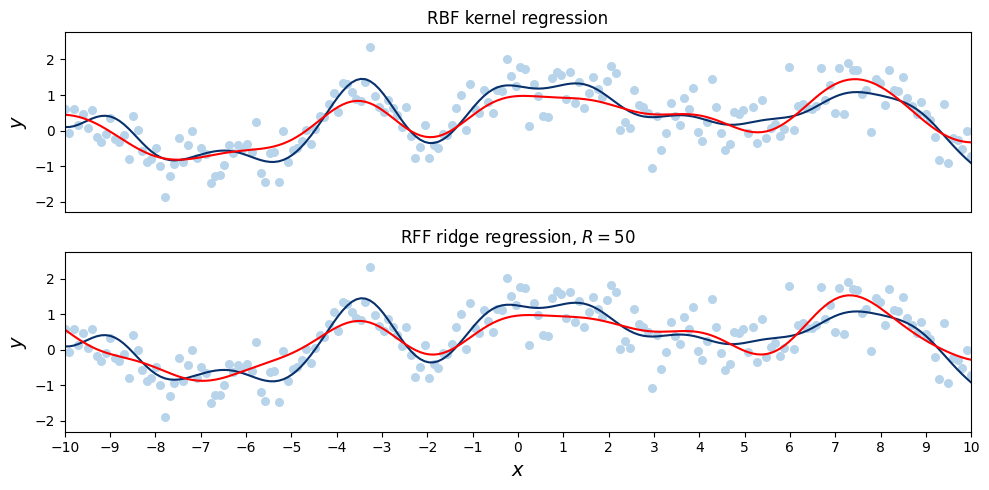

In [16]:
# Set up figure and plot data.
fig, axes = plt.subplots(2, 1)
fig.set_size_inches(10, 5)
ax1, ax2  = axes
cmap      = plt.cm.get_cmap('Blues')

ax1.scatter(X, y, s=30, c=[cmap(0.3)])
ax2.scatter(X, y, s=30, c=[cmap(0.3)])
ax1.plot(X, y_true, c=cmap(1.))
ax2.plot(X, y_true, c=cmap(1.))

# Fit kernel ridge regression using an RBF kernel.
clf    = KernelRidge(kernel=RBF())
clf    = clf.fit(X_train, y_train)
y_pred = clf.predict(X)
ax1.plot(X, y_pred, c='red')

# Fit kernel ridge regression using random Fourier features.
rff_dim = 50
clf     = RFFRidgeRegression(rff_dim=rff_dim)
clf.fit(X_train, y_train)
y_pred  = clf.predict(X)
ax2.plot(X, y_pred, c='red')

# Labels, etc.
ax1.margins(0, 0.1)
ax1.set_title('RBF kernel regression')
ax1.set_ylabel(r'$y$', fontsize=14)
ax1.set_xticks([])
ax2.margins(0, 0.1)
ax2.set_title(rf'RFF ridge regression, $R = {rff_dim}$')
ax2.set_ylabel(r'$y$', fontsize=14)
ax2.set_xlabel(r'$x$', fontsize=14)
ax2.set_xticks(np.arange(-10, 10.1, 1))
plt.tight_layout()
plt.show()

Now we are going to compare the performances and the speed of the classical kernel ridge regression and the random Fourier Features method on a classification task. We are going to use the MNIST dataset (images of digits). To reduce the dimensionnality of the dataset we are going to use PCA and select only the 128 most relevants features.

In [17]:
import torch
import torchvision
from torchvision import datasets
import os
from pathlib import Path

ROOT_DIR = Path.home()
data_path = os.path.join(ROOT_DIR,'data/MNIST/')
#root_dir = './data/MNIST/'
#torchvision.datasets.MNIST(root=data_path,download=True)

train_set = torchvision.datasets.MNIST(root=data_path, train=True, download=True)
test_set = torchvision.datasets.MNIST(root=data_path, train=False, download=True)

def MNIST_numpy(dataset):
    images = dataset.data.numpy().astype(np.float32)/255-0.5
    labels = dataset.targets.numpy()
    return images.reshape((-1,28*28)), labels

MNIST_train, y_train = MNIST_numpy(train_set)
MNIST_test, y_test = MNIST_numpy(test_set)

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.30MB/s]


In [18]:
print(MNIST_train.shape,y_train.shape)

(60000, 784) (60000,)


In [19]:
def mat_transform_pca(Xs, dim=128):
    _, V = np.linalg.eig(Xs.T.dot(Xs))
    return np.real(V[:, :dim])

T = mat_transform_pca(MNIST_train)

In [20]:
X_train = MNIST_train.dot(T)
X_test = MNIST_test.dot(T)

In [21]:
print(X_test.shape)

(10000, 128)


4. Compare the performances and compute time of KRR and RFFRR on a classification task. For the RFFRR we are going to use the [`LinearSVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.htmlfunction). You can play with the hyperparameters (number of random features and variance of the kernel).

In [22]:
from sklearn.svm import SVC

svc = SVC(kernel = "rbf")

In [23]:
%%time
svc.fit(X_train, y_train)

CPU times: user 2min 4s, sys: 408 ms, total: 2min 5s
Wall time: 2min 6s


SVC()

In [24]:
%%time
score = 100 * svc.score(X_test, y_test)
score

CPU times: user 20.5 s, sys: 11.1 ms, total: 20.5 s
Wall time: 20.6 s


96.96000000000001

In [25]:
from sklearn.svm import LinearSVC

class RFFClassif:
    def __init__(self, rff_dim=1, sigma=1.0):
        self.fitted  = False
        self.rff_dim = rff_dim
        self.sigma   = sigma
        self.lm      = LinearSVC()
        self.B_      = None
        self.W_      = None

    def _get_rffs(self, X):
        N, D = X.shape
        if self.W_ is None:
            self.W_ = (1.0 / self.sigma) * np.random.normal(size=(self.rff_dim, D))
            self.B_ = np.random.uniform(0, 2 * np.pi, size=(self.rff_dim, 1))

        projection = self.W_ @ X.T + self.B_
        Z = np.sqrt(2.0 / self.rff_dim) * np.cos(projection)
        return Z.T

    def fit(self, X, y):
        Z = self._get_rffs(X)
        self.lm.fit(Z, y)
        self.fitted = True
        return self

    def predict(self, X):
        Z = self._get_rffs(X)
        return self.lm.predict(Z)

    def score(self, X, y):
        from sklearn.metrics import accuracy_score
        return accuracy_score(y, self.predict(X))

In [26]:
rffsvc = RFFClassif(rff_dim=200, sigma=10.)

In [27]:
%%time
rffsvc.fit(X_train, y_train)

CPU times: user 32.4 s, sys: 138 ms, total: 32.6 s
Wall time: 32.5 s


In [28]:
%%time
rffsvc.score(X_test, y_test)

CPU times: user 151 ms, sys: 1.74 ms, total: 153 ms
Wall time: 134 ms


0.928